# Code to generate the thesis plots

To generate different plots depending on different simulations change the simulation path before the .csv filename. The last two simulations do not have the final stats inside the .csv files because of the error reported by Francesco in the group chat, however the file packet_result.csv was correctly populated and it is the one used to generate the first two plots, so we can use those simulations anyway. If you try you see that the results are very close to ones presented in the thesis.

In [2]:
low_load_sim = "project/simulations/sim_2025-09-02_17:49:15_shortest/"
heavy_load_sim = "project/simulations/sim_2025-09-02_17:49:16_shortest/"
low_load_sim_centflow = "project/simulations/sim_2025-09-02_17:49:13_centflow/"
heavy_load_sim_centflow = "project/simulations/sim_2025-09-02_17:49:14_centflow/"


graph_path = "project/file/graph_networkx_15_nodes.json"

# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
import json

## Heatmap of the fraction of bits received by each node from the other nodes in the network

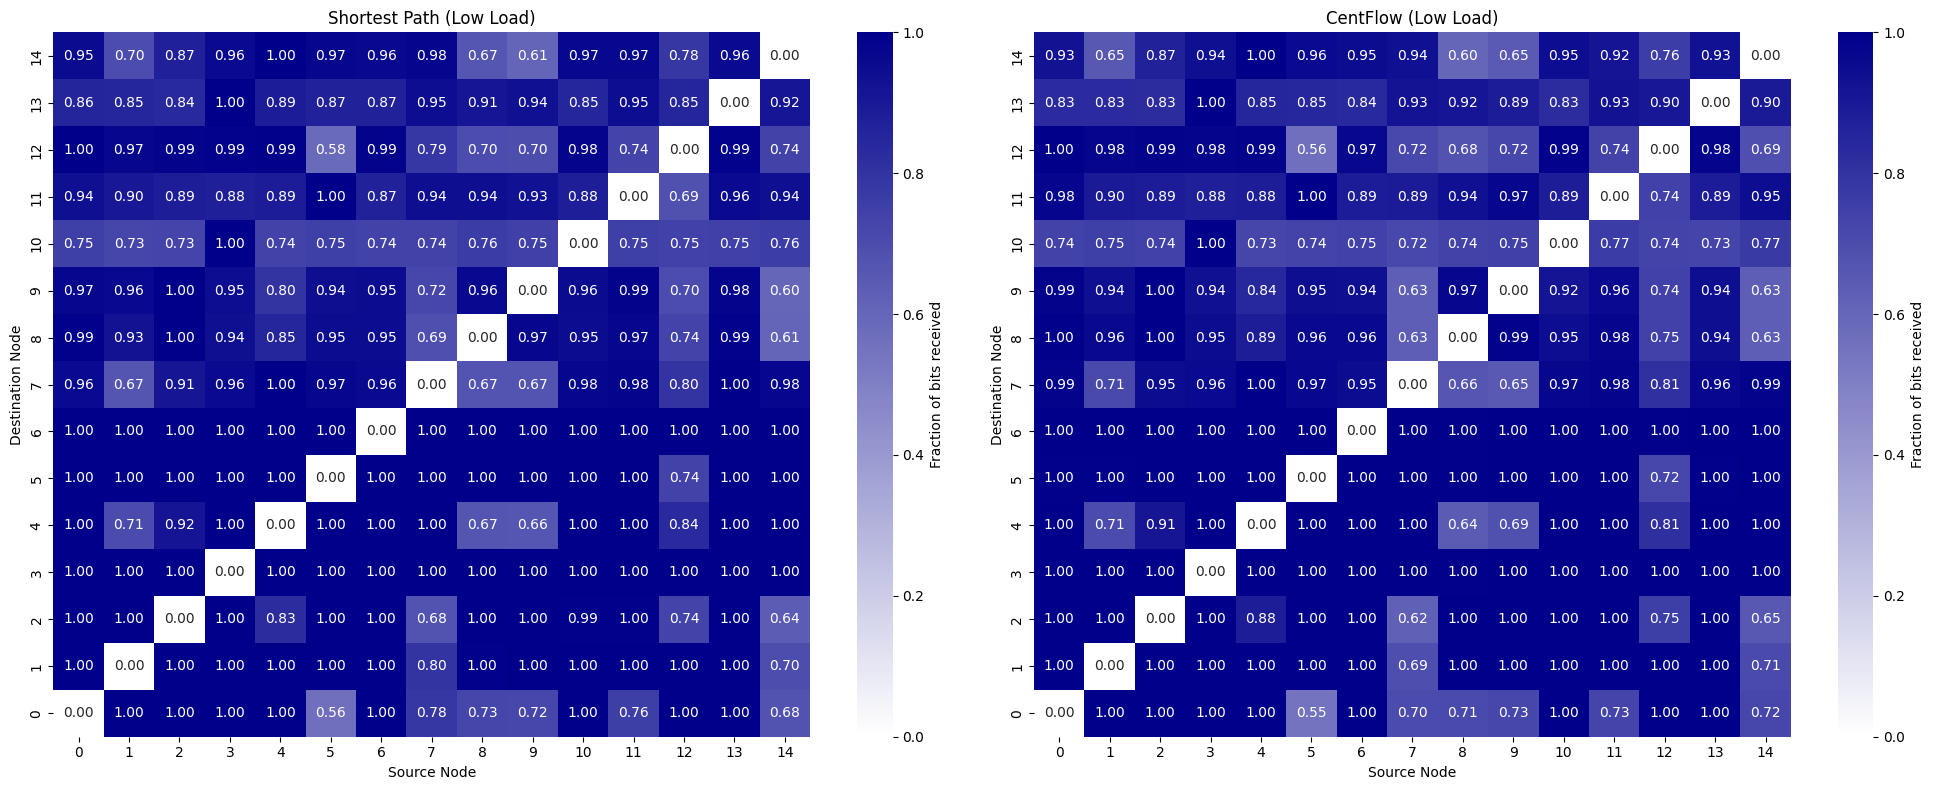

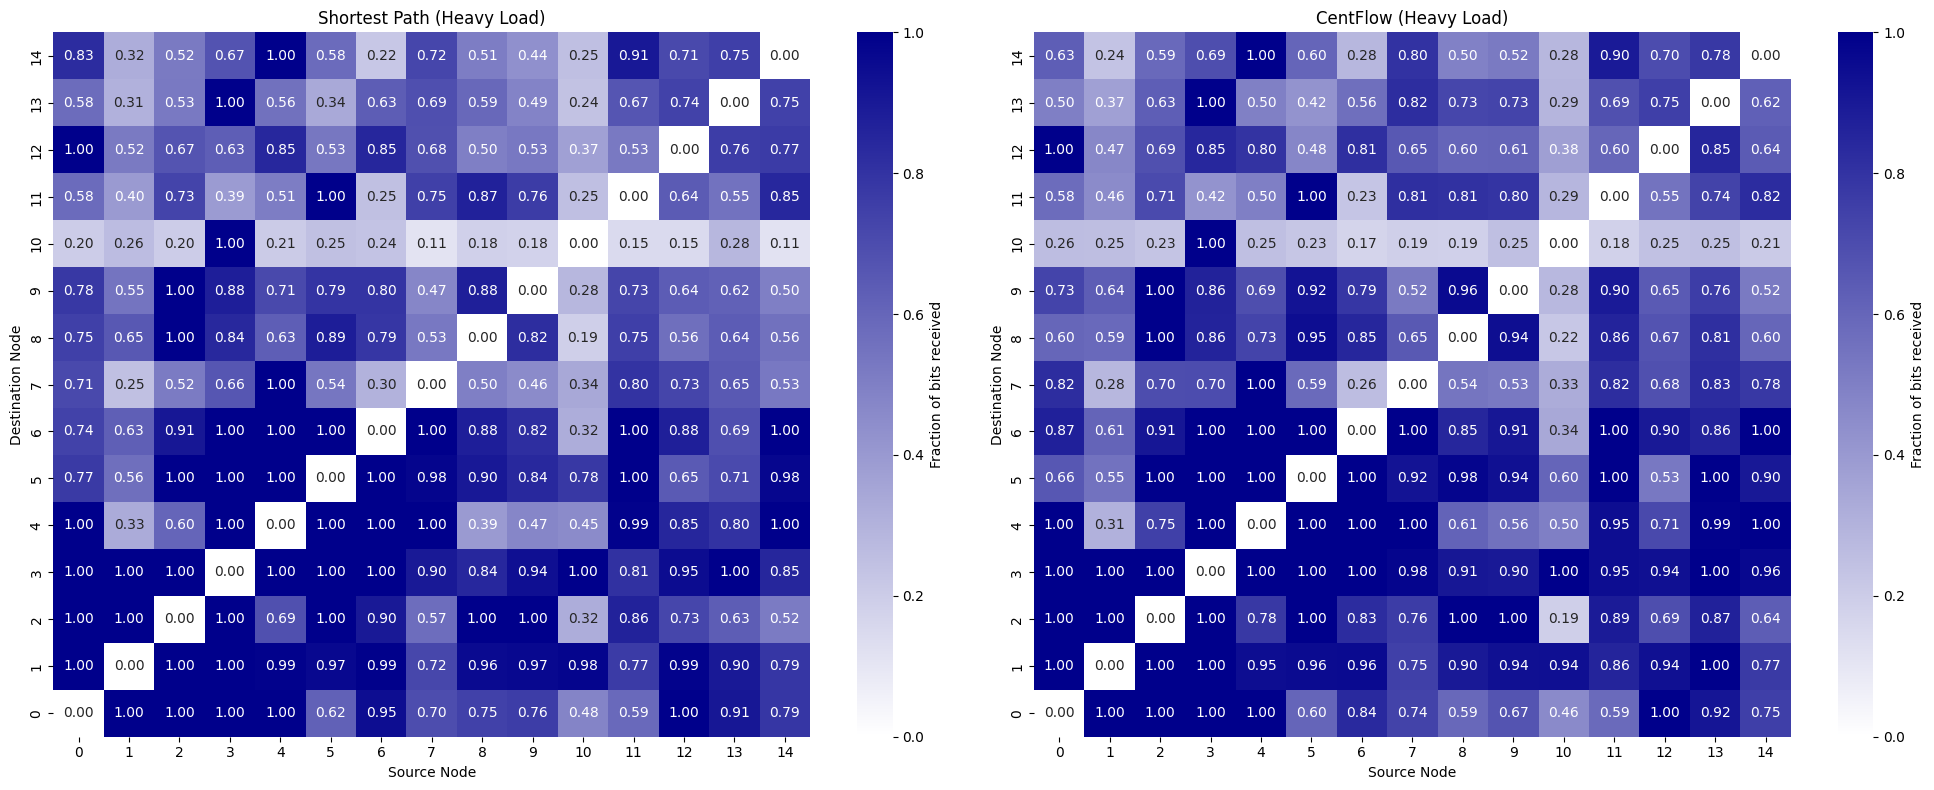

Average of received bits for shortest with low load0.909568149272299
Average of received bits for centflow with low load0.9050270780486112
Average of received bits for shortest with heavy load0.7094429479011853
Average of received bits for centflow with heavy load0.731750924819844


In [ ]:
def extract_fraction_received_bits(file):
    df = pd.read_csv(file)
    df["Sent"] = df["Sent"].astype(bool)
    df["Delivered"] = df["Delivered"].astype(bool)

    df_sent = df[df["Sent"] == True]

    # Group by Source and Destination and compute sent and delivered counts
    grouped = df_sent.groupby(["Source", "Destination"]).agg(
        sent_packets=("Sent", "count"),
        delivered_packets=("Delivered", "sum")
    ).reset_index()

    # Compute fraction of delivered over sent
    grouped["fraction_received"] = grouped["delivered_packets"] / grouped["sent_packets"]

    return grouped   # <-- return the full DataFrame, not just the Series


def heatmap(grouped, title: str):
    heatmap_data = grouped.pivot(index="Destination", columns="Source", values="fraction_received")
    heatmap_data = heatmap_data.fillna(0)

    # Strip 'node' prefix from rows and columns
    heatmap_data.index = heatmap_data.index.str.replace("node", "", regex=False).astype(int)
    heatmap_data.columns = heatmap_data.columns.str.replace("node", "", regex=False).astype(int)

    # Sort rows and columns
    heatmap_data = heatmap_data.sort_index(axis=0)  # rows
    heatmap_data = heatmap_data.sort_index(axis=1)  # columns

    heatmap_data = heatmap_data.reindex(index=heatmap_data.index[::-1])

    cmap = mcolors.LinearSegmentedColormap.from_list("white_to_darkblue", ["white", "#00008B"])
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".2f",
        cmap=cmap,
        vmin=0,
        vmax=1,
        cbar_kws={"label": "Fraction of bits received"}
    )

    plt.title(f"Fraction of bits received (Destination vs Source), {title}")
    plt.xlabel("Source Node")
    plt.ylabel("Destination Node")
    plt.show()


def compare_heatmaps(grouped1, title1: str, grouped2, title2: str):
    """Display two heatmaps side by side for comparison."""
    def prepare_heatmap_data(grouped):
        heatmap_data = grouped.pivot(index="Destination", columns="Source", values="fraction_received")
        heatmap_data = heatmap_data.fillna(0)
        heatmap_data.index = heatmap_data.index.str.replace("node", "", regex=False).astype(int)
        heatmap_data.columns = heatmap_data.columns.str.replace("node", "", regex=False).astype(int)
        heatmap_data = heatmap_data.sort_index(axis=0)
        heatmap_data = heatmap_data.sort_index(axis=1)
        heatmap_data = heatmap_data.reindex(index=heatmap_data.index[::-1])
        return heatmap_data

    data1 = prepare_heatmap_data(grouped1)
    data2 = prepare_heatmap_data(grouped2)

    cmap = mcolors.LinearSegmentedColormap.from_list("white_to_darkblue", ["white", "#00008B"])

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    sns.heatmap(
        data1,
        annot=True,
        fmt=".2f",
        cmap=cmap,
        vmin=0,
        vmax=1,
        cbar_kws={"label": "Fraction of bits received"},
        ax=axes[0]
    )
    axes[0].set_title(title1)
    axes[0].set_xlabel("Source Node")
    axes[0].set_ylabel("Destination Node")

    sns.heatmap(
        data2,
        annot=True,
        fmt=".2f",
        cmap=cmap,
        vmin=0,
        vmax=1,
        cbar_kws={"label": "Fraction of bits received"},
        ax=axes[1]
    )
    axes[1].set_title(title2)
    axes[1].set_xlabel("Source Node")
    axes[1].set_ylabel("Destination Node")

    plt.tight_layout()
    plt.show()


short_low = extract_fraction_received_bits(f"{low_load_sim}packet_result.csv")
centflow_low = extract_fraction_received_bits(f'{low_load_sim_centflow}packet_result.csv')
short_heavy = extract_fraction_received_bits(f"{heavy_load_sim}packet_result.csv")
centflow_heavy = extract_fraction_received_bits(f'{heavy_load_sim_centflow}packet_result.csv')


'''
heatmap(short_low, "shortest low load")
heatmap(centflow_low, "centflow low load")
heatmap(short_heavy, "shortest heavy load")
heatmap(centflow_heavy, "centflow heavy load")
'''


compare_heatmaps(short_low, "Shortest Path (Low Load)",
                 centflow_low, "CentFlow (Low Load)")
compare_heatmaps(short_heavy, "Shortest Path (Heavy Load)",
                 centflow_heavy, "CentFlow (Heavy Load)")


print("Average of received bits for shortest with low load: " + str(short_low["fraction_received"].mean()))
print("Average of received bits for centflow with low load: " + str(centflow_low["fraction_received"].mean()))
print("Average of received bits for shortest with heavy load: " + str(short_heavy["fraction_received"].mean()))
print("Average of received bits for centflow with heavy load: " + str(centflow_heavy["fraction_received"].mean()))

## Number of received bits for each node

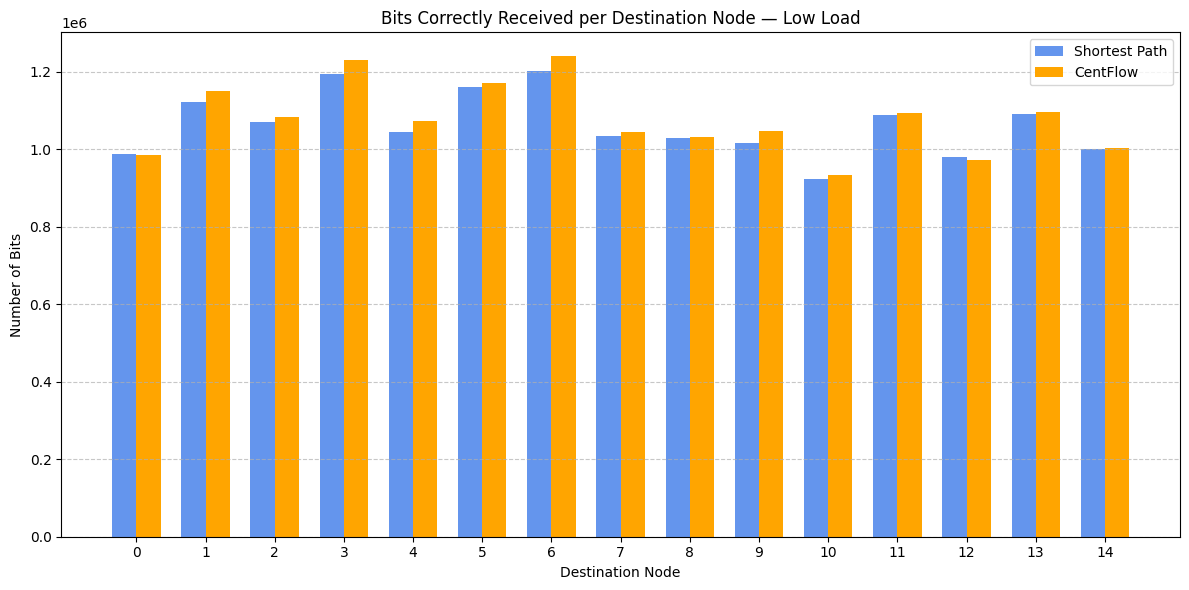

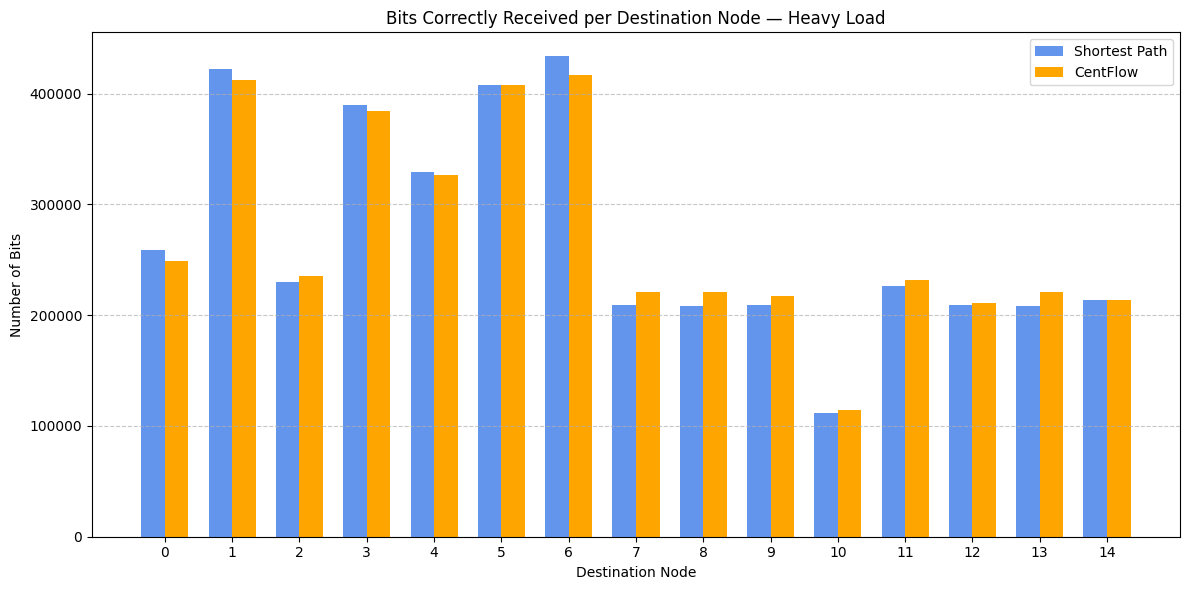

In [9]:
def extract_num_received_bits(file):
    df_packets = pd.read_csv(file)
    df_packets["Destination"] = df_packets["Destination"].str.extract(r"(\d+)", expand=False).astype(int)

    # Filter only delivered packets
    delivered_packets = df_packets[df_packets["Delivered"] == True]

    # Count received packets per destination node
    received_counts = delivered_packets["Destination"].value_counts().sort_index()
    received_bits = received_counts * 128

    # print("Number of correctly received packets per destination node:")
    # print(received_counts)
    return received_bits


def plot_num_received_bits(received_bits, title):
    plt.figure(figsize=(10, 6))
    received_bits.plot(kind="bar", color="cornflowerblue")
    plt.title(f"Bits Correctly Received per Destination Node, {title}")
    plt.xlabel("Destination Node")
    plt.ylabel("Number of Bits")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_comparison(received_bits1, label1, received_bits2, label2, title):
    # Ensure both Series have the same index order
    all_nodes = sorted(set(received_bits1.index) | set(received_bits2.index))
    vals1 = received_bits1.reindex(all_nodes, fill_value=0)
    vals2 = received_bits2.reindex(all_nodes, fill_value=0)

    x = np.arange(len(all_nodes))  # positions on x-axis
    width = 0.35                   # width of each bar

    plt.figure(figsize=(12, 6))
    plt.bar(x - width/2, vals1, width, label=label1, color="cornflowerblue")
    plt.bar(x + width/2, vals2, width, label=label2, color="orange")

    plt.title(f"Bits Correctly Received per Destination Node — {title}")
    plt.xlabel("Destination Node")
    plt.ylabel("Number of Bits")
    plt.xticks(x, all_nodes)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()


short_low_rcv_bits = extract_num_received_bits(f"{low_load_sim}packet_result.csv")
centflow_low_rcv_bits = extract_num_received_bits(f'{low_load_sim_centflow}packet_result.csv')
short_heavy_rcv_bits = extract_num_received_bits(f"{heavy_load_sim}packet_result.csv")
centflow_heavy_rcv_bits = extract_num_received_bits(f'{heavy_load_sim_centflow}packet_result.csv')

'''
plot_num_received_bits(short_low_rcv_bits, "Short Low Load")
plot_num_received_bits(centflow_low_rcv_bits, "Centflow Low Load")
plot_num_received_bits(short_heavy_rcv_bits, "Short Heavy Load")
plot_num_received_bits(centflow_heavy_rcv_bits, "Centflow Heavy Load")
'''


# Low load comparison
plot_comparison(short_low_rcv_bits, "Shortest Path", 
                centflow_low_rcv_bits, "CentFlow", 
                "Low Load")

# Heavy load comparison
plot_comparison(short_heavy_rcv_bits, "Shortest Path", 
                centflow_heavy_rcv_bits, "CentFlow", 
                "Heavy Load")


## Average of correctly received bits by destination nodes for paths of different lengths

Computing the unique path lengths in the experiments.

In [11]:
with open(graph_path) as f:
    data = json.load(f)
G = nx.node_link_graph(data, edges="links") # type: ignore

all_pairs_lengths = dict(nx.all_pairs_shortest_path_length(G))

# Extract unique path lengths
unique_lengths = set()

for source, length_dict in all_pairs_lengths.items():
    for target, length in length_dict.items():
        if source != target:
            unique_lengths.add(length)

print("Unique shortest path lengths between node pairs in the graph:", sorted(unique_lengths))


def extract_unique_path_lengths(csv_file):
    """
    Given a CSV file with a column 'Num. Hop',
    returns a sorted list of all unique path lengths (hop counts).
    """
    df = pd.read_csv(csv_file)
    
    # The column may contain spaces, so ensure we refer to it correctly:
    # Either 'Num. Hop' or something similar — check the header exactly.
    # If needed, strip leading/trailing whitespace:
    df.columns = df.columns.str.strip()
    
    if "Num. Hop" not in df.columns:
        raise ValueError("Column 'Num. Hop' not found in CSV file.")
    
    unique_hops = sorted(df["Num. Hop"].unique())
    return unique_hops


len_shortest_low = extract_unique_path_lengths(f"{low_load_sim}packet_result.csv")
len_centflow_low = extract_unique_path_lengths(f'{low_load_sim_centflow}packet_result.csv')
len_shortest_heavy = extract_unique_path_lengths(f"{heavy_load_sim}packet_result.csv")
len_centflow_heavy = extract_unique_path_lengths(f'{heavy_load_sim_centflow}packet_result.csv')

print("Path lenghts for shortest in low load: " + str(len_shortest_low))
print("Path lenghts for centflow in low load: " + str(len_centflow_low))
print("Path lenghts for shortest in heavyload: " + str(len_shortest_heavy))
print("Path lenghts for centflow in heavyload: " + str(len_centflow_heavy))

Unique shortest path lengths between node pairs in the graph: [1, 2, 3, 4]
Path lenghts for shortest in low load: [0, 1, 2, 3, 4]
Path lenghts for centflow in low load: [0, 1, 2, 3, 4]
Path lenghts for shortest in heavyload: [0, 1, 2, 3, 4]
Path lenghts for centflow in heavyload: [0, 1, 2, 3, 4]


## Success probability for each path length

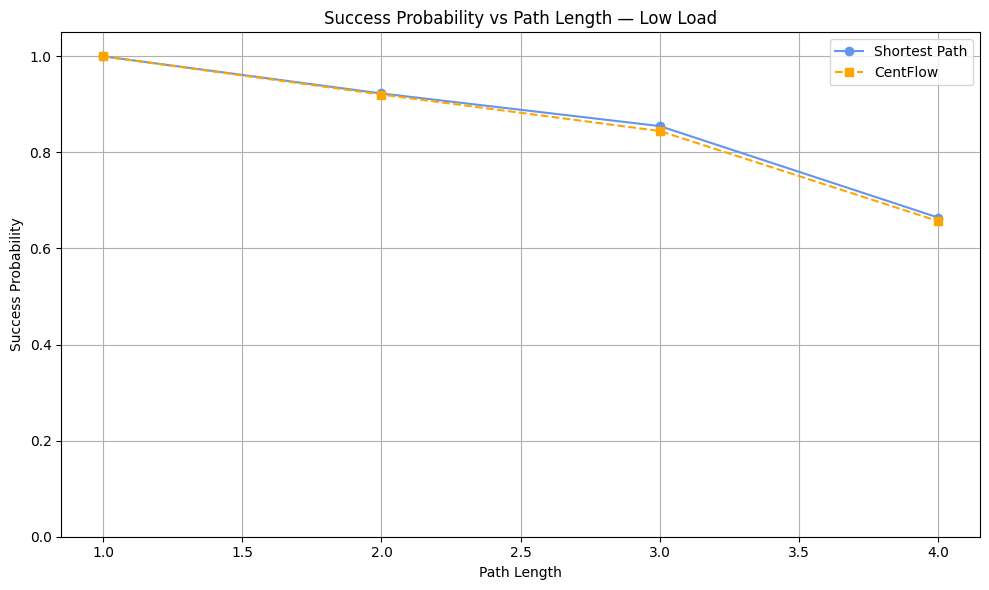

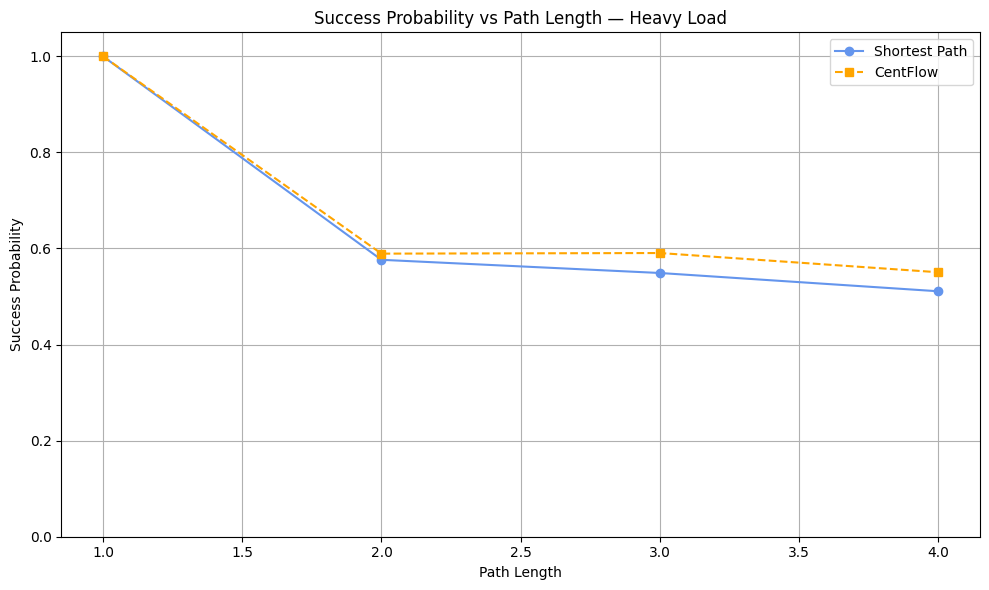

In [10]:
# Calculate and plot success probability for each path length

def extract_success_probability_by_path_length(packet_file, graph_path):
    """Extract success probability grouped by path length from a simulation result."""
    # Load packet results
    df = pd.read_csv(packet_file)
    df["Sent"] = df["Sent"].astype(bool)
    df["Delivered"] = df["Delivered"].astype(bool)

    # Load graph and compute shortest path lengths
    with open(graph_path) as f:
        data = json.load(f)
    G = nx.node_link_graph(data, edges="links")  # type: ignore
    all_pairs_lengths = dict(nx.all_pairs_shortest_path_length(G))

    # Build mapping from (source, dest) to path length
    path_length_dict = {}
    for src, targets in all_pairs_lengths.items():
        for dst, length in targets.items():
            if src != dst:
                path_length_dict[(str(src), str(dst))] = length

    # Add path length to each packet row
    def get_path_length(row):
        src = row["Source"].replace("node", "")
        dst = row["Destination"].replace("node", "")
        return path_length_dict.get((src, dst), None)

    df["path_length"] = df.apply(get_path_length, axis=1)  # type: ignore

    # Filter only sent packets
    df_sent = df[df["Sent"] == True]

    # Group by path length and calculate success probability
    grouped = df_sent.groupby("path_length").agg(
        sent_packets=("Sent", "count"),
        delivered_packets=("Delivered", "sum")
    ).reset_index()

    grouped["success_probability"] = grouped["delivered_packets"] / grouped["sent_packets"]

    return grouped  # DataFrame with columns: path_length, sent_packets, delivered_packets, success_probability


'''
# Bar plot for better representation
plt.figure(figsize=(8, 5))
plt.bar(grouped["path_length"], grouped["success_probability"], color="skyblue")
plt.title(f"Success Probability by Path Length (Bar) ({title})")
plt.xlabel("Path Length")
plt.ylabel("Success Probability")
plt.ylim(0, 1.05)
plt.grid(axis="y")
plt.tight_layout()
plt.show()
'''


def plot_success_probability_comparison(grouped1, label1, grouped2, label2, title):
    """Plot success probability vs path length for two simulations on the same plot."""
    plt.figure(figsize=(10, 6))
    plt.plot(grouped1["path_length"], grouped1["success_probability"], marker="o", linestyle="-",
             label=label1, color="cornflowerblue")
    plt.plot(grouped2["path_length"], grouped2["success_probability"], marker="s", linestyle="--",
             label=label2, color="orange")

    plt.title(f"Success Probability vs Path Length — {title}")
    plt.xlabel("Path Length")
    plt.ylabel("Success Probability")
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Extract data ---
short_low_success = extract_success_probability_by_path_length(f"{low_load_sim}packet_result.csv", graph_path)
centflow_low_success = extract_success_probability_by_path_length(f"{low_load_sim_centflow}packet_result.csv", graph_path)
short_heavy_success = extract_success_probability_by_path_length(f"{heavy_load_sim}packet_result.csv", graph_path)
centflow_heavy_success = extract_success_probability_by_path_length(f"{heavy_load_sim_centflow}packet_result.csv", graph_path)

# --- Plot comparisons ---
# Low load comparison
plot_success_probability_comparison(short_low_success, "Shortest Path",
                                    centflow_low_success, "CentFlow",
                                    "Low Load")

# Heavy load comparison
plot_success_probability_comparison(short_heavy_success, "Shortest Path",
                                    centflow_heavy_success, "CentFlow",
                                    "Heavy Load")
